# Notebook 3 - Analysis

Route-level TWFE DiD estimates of the effect of the Russia/Ukraine airspace closure (24 February 2022) on flight operations and CO2 emissions.

## 1. Imports and load panel

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from linearmodels.panel import PanelOLS
from scipy import stats
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})
C = {'primary':'#1A4A8A','secondary':'#C0392B','neutral':'#888780','highlight':'#2DBDB6'}

CLEAN_DIR  = Path.home() / 'econ62020' / 'clean'
OUTPUT_DIR = CLEAN_DIR

route_panel_nc = pd.read_parquet(CLEAN_DIR / 'route_panel_nc_co2.parquet')
print(f'route_panel_nc: {route_panel_nc.shape}')

route_panel_nc: (783057, 46)


## 2. TWFE estimator functions

In [2]:
# Canonical route ID for SE clustering
route_panel_nc['ORIG_ICAO'] = route_panel_nc['AIRP_PR'].str.split('_').str[1]
route_panel_nc['DEST_ICAO'] = route_panel_nc['AIRP_PR'].str.split('_').str[3]
route_panel_nc['ROUTE_CANONICAL'] = route_panel_nc.apply(
    lambda r: '_'.join(sorted([r['ORIG_ICAO'], r['DEST_ICAO']])), axis=1
)

In [3]:
def run_twfe(outcome, data, treatment='DID', label=''):
    d = data.dropna(subset=[outcome, treatment]).copy()
    d = d.set_index(['ROUTE_CANONICAL', 'TIME'])
    res = PanelOLS(
        d[outcome], d[[treatment]],
        entity_effects=True, time_effects=True
    ).fit(cov_type='clustered', cluster_entity=True)
    c, p = res.params[treatment], res.pvalues[treatment]
    s = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else 'n.s.'))
    if label:
        print(f'  {label:<25} beta={c:+.4f} [{s}]  SE={res.std_errors[treatment]:.4f}  p={p:.4f}  N={int(res.nobs):,}')
    return res

def run_twfe_het(outcome, data, label=''):
    """
    Heterogeneous TWFE with separate terms for Russia-only, Ukraine-only, and Both.
    """
    vars_ = ['DID_RUSSIA', 'DID_UKRAINE', 'DID_BOTH']
    d = data.dropna(subset=[outcome]+vars_).copy()
    d = d.set_index(['ROUTE_CANONICAL', 'TIME'])
    res = PanelOLS(
        d[outcome], d[vars_],
        entity_effects=True, time_effects=True
    ).fit(cov_type='clustered', cluster_entity=True)
    if label:
        print(f'  {label}')
        for v in vars_:
            c, p = res.params[v], res.pvalues[v]
            s = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else 'n.s.'))
            print(f'    {v:<15} beta={c:+.4f} [{s}]  SE={res.std_errors[v]:.4f}  p={p:.4f}')
    return res

def stars(p):
    return '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''

## 3. Main results

Binary TWFE DiD: route transited closed airspace x post-closure (Feb 2022+). COVID years excluded. GB dropped post-2019.

In [4]:
MAIN_OUTCOMES = [
    ('LOG_FLIGHTS',    'Log Flights'),
    ('LOG_PASSENGERS', 'Log Passengers'),
    ('LOG_SEATS',      'Log Seats'),
    ('LOAD_FACTOR',    'Load Factor'),
    ('LOG_CO2_ADJ_EST','Log CO2 (adj. est.)'),
]

print('='*70)
print('Route-level TWFE DiD | FIR boundaries and great-circle paths')
print('Route + month-year FE | SE clustered by route pair | COVID excluded')
print('='*70)

results = {}
for outcome, label in MAIN_OUTCOMES:
    try:
        results[outcome] = run_twfe(outcome, route_panel_nc, label=label)
    except Exception as e:
        print(f'  {label}: ERROR — {e}')

Route-level TWFE DiD | FIR boundaries and great-circle paths
Route + month-year FE | SE clustered by route pair | COVID excluded
  Log Flights               beta=-0.0768 [***]  SE=0.0295  p=0.0093  N=779,438
  Log Passengers            beta=-0.1642 [***]  SE=0.0309  p=0.0000  N=734,912
  Log Seats                 beta=-0.1040 [***]  SE=0.0292  p=0.0004  N=760,871
  Load Factor               beta=-0.0050 [n.s.]  SE=0.0053  p=0.3430  N=713,424
  Log CO2 (adj. est.)       beta=-0.0269 [n.s.]  SE=0.0276  p=0.3307  N=768,217


### LaTeX table

In [5]:
def interpret_beta(outcome, beta):
    return f'{beta:.4f}' if outcome == 'LOAD_FACTOR' else f'{100*(np.exp(beta)-1):.2f}\\%'

coef_row   = ['Affected $\\times$ Post']
se_row     = ['']
effect_row = ['Approx. effect']
obs_row    = ['Observations']
routes_row = ['Route pairs']
fe_row     = ['Route + month-year FE']
se_cl_row  = ['Clustered SE']

for outcome, label in MAIN_OUTCOMES:
    if outcome not in results: continue
    res  = results[outcome]
    beta = res.params['DID']
    se   = res.std_errors['DID']
    p    = res.pvalues['DID']
    coef_row.append(f'{beta:.4f}{stars(p)}')
    se_row.append(f'({se:.4f})')
    effect_row.append(interpret_beta(outcome, beta))
    obs_row.append(f'{int(res.nobs):,}')
    d = route_panel_nc.dropna(subset=[outcome,'DID'])
    routes_row.append(f'{d["ROUTE_CANONICAL"].nunique():,}')
    fe_row.append('Yes'); se_cl_row.append('Route pair')

ncols    = len(MAIN_OUTCOMES)
col_spec = 'l' + 'c'*ncols
headers  = ' & '.join([l for _, l in MAIN_OUTCOMES])

latex = (
    r'\begin{table*}[!t]\centering' + '\n'
    r'\caption{Effect of Airspace Closure on Route-Level Outcomes}' + '\n'
    r'\label{tab:main_results}\small' + '\n'
    f'\\begin{{tabular}}{{{col_spec}}}\n\\hline\n'
    f' & {headers} \\\\\n\\hline\n'
    + ' & '.join(coef_row)   + ' \\\\\n'
    + ' & '.join(se_row)     + ' \\\\\n'
    + ' & '.join(effect_row) + ' \\\\\n\\hline\n'
    + ' & '.join(obs_row)    + ' \\\\\n'
    + ' & '.join(routes_row) + ' \\\\\n'
    + ' & '.join(fe_row)     + ' \\\\\n'
    + ' & '.join(se_cl_row)  + ' \\\\\n'
    + r'\hline\end{tabular}' + '\n'
    + r'\begin{flushleft}\footnotesize' + '\n'
    + r'Notes: Route-level TWFE. Treatment: Affected $\times$ Post. '
    + r'For logged outcomes, approx. effect $= 100\times(\exp(\beta)-1)$. '
    + r'* $p<0.10$, ** $p<0.05$, *** $p<0.01$.\end{flushleft}\end{table*}'
)
print(latex)

\begin{table*}[!t]\centering
\caption{Effect of Airspace Closure on Route-Level Outcomes}
\label{tab:main_results}\small
\begin{tabular}{lccccc}
\hline
 & Log Flights & Log Passengers & Log Seats & Load Factor & Log CO2 (adj. est.) \\
\hline
Affected $\times$ Post & -0.0768*** & -0.1642*** & -0.1040*** & -0.0050 & -0.0269 \\
 & (0.0295) & (0.0309) & (0.0292) & (0.0053) & (0.0276) \\
Approx. effect & -7.40\% & -15.14\% & -9.88\% & -0.0050 & -2.65\% \\
\hline
Observations & 779,438 & 734,912 & 760,871 & 713,424 & 768,217 \\
Route pairs & 9,752 & 9,412 & 9,684 & 9,309 & 9,514 \\
Route + month-year FE & Yes & Yes & Yes & Yes & Yes \\
Clustered SE & Route pair & Route pair & Route pair & Route pair & Route pair \\
\hline\end{tabular}
\begin{flushleft}\footnotesize
Notes: Route-level TWFE. Treatment: Affected $\times$ Post. For logged outcomes, approx. effect $= 100\times(\exp(\beta)-1)$. * $p<0.10$, ** $p<0.05$, *** $p<0.01$.\end{flushleft}\end{table*}


## 4. Heterogeneity: Russia vs Ukraine exposure

Separate DiD terms for routes exposed to 
- Russian airspace only, 
- Ukrainian airspace only, 
- Both Russian and Ukrainian airspace.

In [6]:
HET_OUTCOMES = [
    ('LOG_FLIGHTS',    'Log Flights'),
    ('LOG_PASSENGERS', 'Log Passengers'),
    ('LOG_SEATS',      'Log Seats'),
    ('LOAD_FACTOR',    'Load Factor'),
    ('LOG_CO2_ADJ_EST','Log CO2 (adj. est.)'),
]

print('='*70)
print('Heterogeneity: Russia-only vs Ukraine-only vs Both')
print('Route + month-year FE | SE clustered by route pair')
print('='*70)

het_results = {}
for outcome, label in HET_OUTCOMES:
    try:
        het_results[outcome] = run_twfe_het(outcome, route_panel_nc, label=label)
    except Exception as e:
        print(f'  {label}: ERROR — {e}')

Heterogeneity: Russia-only vs Ukraine-only vs Both
Route + month-year FE | SE clustered by route pair
  Log Flights
    DID_RUSSIA      beta=-0.3028 [***]  SE=0.0426  p=0.0000
    DID_UKRAINE     beta=+0.0386 [n.s.]  SE=0.0367  p=0.2921
    DID_BOTH        beta=+0.0276 [n.s.]  SE=0.0870  p=0.7514
  Log Passengers
    DID_RUSSIA      beta=-0.3797 [***]  SE=0.0461  p=0.0000
    DID_UKRAINE     beta=+0.0005 [n.s.]  SE=0.0380  p=0.9895
    DID_BOTH        beta=-0.3049 [***]  SE=0.0731  p=0.0000
  Log Seats
    DID_RUSSIA      beta=-0.3363 [***]  SE=0.0416  p=0.0000
    DID_UKRAINE     beta=+0.0151 [n.s.]  SE=0.0377  p=0.6881
    DID_BOTH        beta=+0.0019 [n.s.]  SE=0.0762  p=0.9804
  Load Factor
    DID_RUSSIA      beta=-0.0303 [***]  SE=0.0098  p=0.0019
    DID_UKRAINE     beta=+0.0108 [*]  SE=0.0061  p=0.0746
    DID_BOTH        beta=-0.0024 [n.s.]  SE=0.0137  p=0.8620
  Log CO2 (adj. est.)
    DID_RUSSIA      beta=-0.1794 [***]  SE=0.0403  p=0.0000
    DID_UKRAINE     beta=+0.0444 [n

## 5. Continuous treatment intensity

Replaces binary DID with: DID_INTENSITY = (REROUTE_RATIO − 1) x POST. Tests dose-response: larger rerouting penalty = larger effect.

Base penalties: none=0.00, low=0.01, medium=0.16, high=0.43.

In [7]:
print('DID_INTENSITY distribution (post-period, affected routes):')
mask = (route_panel_nc['POST']==1) & (route_panel_nc['AFFECTED']==1)
print(route_panel_nc.loc[mask,'DID_INTENSITY'].describe().round(4))
print()
print(route_panel_nc[mask].groupby('EXPOSURE_GROUP')['DID_INTENSITY']
      .agg(['count','mean','min','max']).round(4))

INTENSITY_OUTCOMES = [
    ('LOG_FLIGHTS',     'Log Flights'),
    ('LOG_PASSENGERS',  'Log Passengers'),
    ('LOG_SEATS',       'Log Seats'),
    ('LOAD_FACTOR',     'Load Factor'),
    ('LOG_CO2_ADJ_EST', 'Log CO2 (adj. est.)'),
]

intensity_results = {}
for outcome, label in INTENSITY_OUTCOMES:
    d = route_panel_nc.dropna(subset=[outcome,'DID_INTENSITY']).copy()
    d = d.set_index(['ROUTE_CANONICAL','TIME'])
    try:
        res = PanelOLS(d[outcome], d[['DID_INTENSITY']],
                       entity_effects=True, time_effects=True
                       ).fit(cov_type='clustered', cluster_entity=True)
        intensity_results[outcome] = {
            'coef': res.params['DID_INTENSITY'],
            'se':   res.std_errors['DID_INTENSITY'],
            'pval': res.pvalues['DID_INTENSITY'],
            'nobs': int(res.nobs),
        }
    except Exception as e:
        print(f'{label}: ERROR — {e}')

print('\n' + '='*80)
print('Binary DID vs Continuous Intensity')
print('='*80)
print(f'{"Outcome":<30} {"Binary β":>9} {"Intensity β":>12} {"Int. p":>8} {"Sig":>5}')
print('-'*80)
for outcome, label in INTENSITY_OUTCOMES:
    if outcome not in intensity_results: continue
    r   = intensity_results[outcome]
    sig = stars(r['pval']) or 'n.s.'
    bc  = results[outcome].params['DID'] if outcome in results else float('nan')
    print(f'{label:<30} {bc:>+9.4f} {r["coef"]:>+12.4f} {r["pval"]:>8.4f} {sig:>5}')

DID_INTENSITY distribution (post-period, affected routes):
count    7320.0000
mean        0.0458
std         0.0836
min         0.0000
25%         0.0000
50%         0.0100
75%         0.0100
max         0.4300
Name: DID_INTENSITY, dtype: float64

                count  mean   min   max
EXPOSURE_GROUP                         
high              143  0.43  0.43  0.43
low              2464  0.01  0.01  0.01
medium           1555  0.16  0.16  0.16
none             3158  0.00  0.00  0.00

Binary DID vs Continuous Intensity
Outcome                         Binary β  Intensity β   Int. p   Sig
--------------------------------------------------------------------------------
Log Flights                      -0.0768      -1.8439   0.0000   ***
Log Passengers                   -0.1642      -2.2124   0.0000   ***
Log Seats                        -0.1040      -1.8760   0.0000   ***
Load Factor                      -0.0050      -0.2136   0.0000   ***
Log CO2 (adj. est.)              -0.0269      -0.9

## 6. Decomposition: volume vs rerouting-distance channel

In [8]:
beta_flights  = results['LOG_FLIGHTS'].params['DID']
beta_co2      = results['LOG_CO2_ADJ_EST'].params['DID']
beta_distance = beta_co2 - beta_flights

pct_flights  = 100*(np.exp(beta_flights)  - 1)
pct_co2      = 100*(np.exp(beta_co2)      - 1)
pct_distance = 100*(np.exp(beta_distance) - 1)

print('Flight volume effect:')
print(f'  beta = {beta_flights:+.4f}  ({pct_flights:+.2f}%)')
print('Combined CO2 effect:')
print(f'  beta = {beta_co2:+.4f}  ({pct_co2:+.2f}%)')
print('Implied rerouting-distance channel (CO2 - flights):')
print(f'  beta = {beta_distance:+.4f}  ({pct_distance:+.2f}%)')

Flight volume effect:
  beta = -0.0768  (-7.40%)
Combined CO2 effect:
  beta = -0.0269  (-2.65%)
Implied rerouting-distance channel (CO2 - flights):
  beta = +0.0499  (+5.12%)


## 7. Distance-band heterogeneity

In [9]:
DIST_BANDS = ['short','medium','long','very_long']

for band in DIST_BANDS:
    route_panel_nc[f'DID_dist_{band}'] = (
        route_panel_nc['DID'] * (route_panel_nc['DIST_BAND'] == band).astype(int)
    )
dist_did_vars = [f'DID_dist_{b}' for b in DIST_BANDS]

print('='*65)
print('Heterogeneity: distance bands')
print('='*65)

dist_het_results = {}
for outcome, label in MAIN_OUTCOMES:
    d = route_panel_nc.dropna(subset=[outcome,'DIST_BAND']+dist_did_vars).copy()
    d = d.set_index(['ROUTE_CANONICAL','TIME'])
    try:
        res = PanelOLS(d[outcome], d[dist_did_vars],
                       entity_effects=True, time_effects=True, drop_absorbed=True
                       ).fit(cov_type='clustered', cluster_entity=True)
        dist_het_results[outcome] = res
        print(f'\n  {label}')
        for band, var in zip(DIST_BANDS, dist_did_vars):
            if var in res.params.index:
                c, p = res.params[var], res.pvalues[var]
                s = stars(p) or 'n.s.'
                print(f'    {band:<12} beta={c:+.4f} [{s}]  SE={res.std_errors[var]:.4f}  p={p:.4f}')
    except Exception as e:
        print(f'  {label}: ERROR — {e}')

Heterogeneity: distance bands

  Log Flights
    medium       beta=+0.1970 [***]  SE=0.0503  p=0.0001
    long         beta=-0.0876 [*]  SE=0.0519  p=0.0915
    very_long    beta=-0.2551 [***]  SE=0.0374  p=0.0000

  Log Passengers
    medium       beta=+0.1396 [**]  SE=0.0598  p=0.0196
    long         beta=-0.0947 [**]  SE=0.0449  p=0.0349
    very_long    beta=-0.3443 [***]  SE=0.0392  p=0.0000

  Log Seats
    medium       beta=+0.1970 [***]  SE=0.0507  p=0.0001
    long         beta=-0.1222 [***]  SE=0.0442  p=0.0057
    very_long    beta=-0.2965 [***]  SE=0.0356  p=0.0000

  Load Factor
    medium       beta=-0.0040 [n.s.]  SE=0.0092  p=0.6651
    long         beta=+0.0198 [**]  SE=0.0094  p=0.0351
    very_long    beta=-0.0188 [**]  SE=0.0077  p=0.0148

  Log CO2 (adj. est.)
    medium       beta=+0.1976 [***]  SE=0.0502  p=0.0001
    long         beta=-0.0758 [n.s.]  SE=0.0516  p=0.1422
    very_long    beta=-0.1508 [***]  SE=0.0347  p=0.0000


## 8. Event study

Month-by-month DiD coefficients on log flights. Base period: January 2022. Pre-trend flatness validates parallel trends.

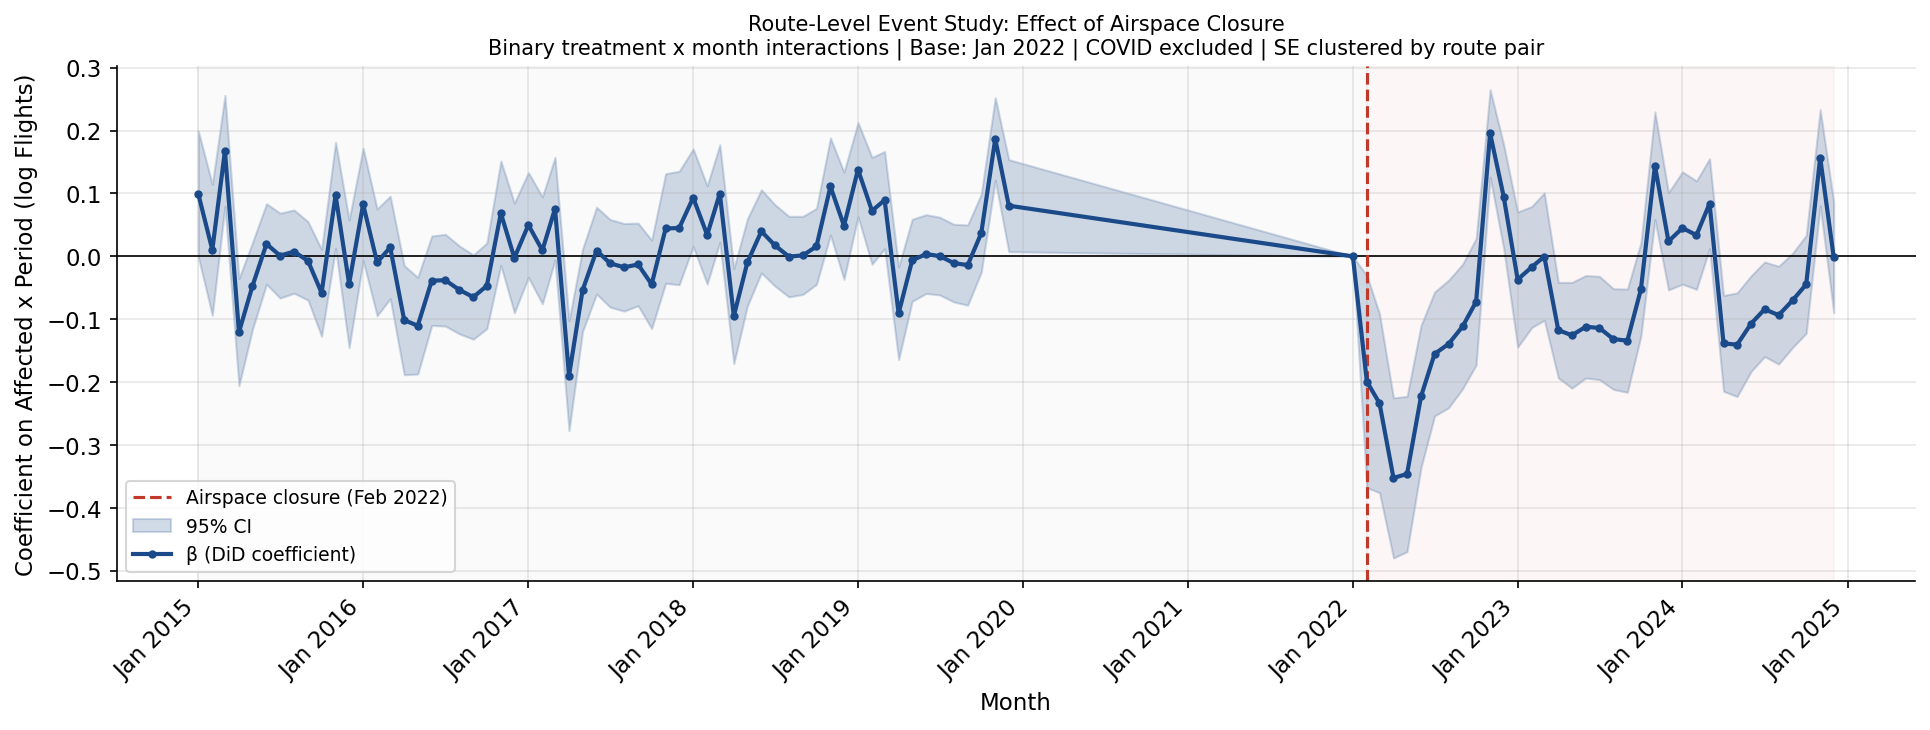

Max |pre-trend coef|: 0.1898
      date    coef     se
2015-01-01  0.0992 0.0511
2015-02-01  0.0104 0.0531
2015-03-01  0.1678 0.0449
2015-04-01 -0.1205 0.0434
2015-05-01 -0.0469 0.0352
2015-06-01  0.0198 0.0327
2015-07-01  0.0013 0.0345
2015-08-01  0.0076 0.0338
2015-09-01 -0.0072 0.0318
2015-10-01 -0.0580 0.0353
2015-11-01  0.0972 0.0431
2015-12-01 -0.0436 0.0518
2016-01-01  0.0828 0.0456
2016-02-01 -0.0095 0.0433
2016-03-01  0.0143 0.0416
2016-04-01 -0.1014 0.0443
2016-05-01 -0.1102 0.0392
2016-06-01 -0.0387 0.0363
2016-07-01 -0.0378 0.0372
2016-08-01 -0.0532 0.0357
2016-09-01 -0.0647 0.0342
2016-10-01 -0.0468 0.0348
2016-11-01  0.0687 0.0423
2016-12-01 -0.0024 0.0445
2017-01-01  0.0500 0.0425
2017-02-01  0.0096 0.0434
2017-03-01  0.0758 0.0416
2017-04-01 -0.1898 0.0446
2017-05-01 -0.0539 0.0334
2017-06-01  0.0092 0.0352
2017-07-01 -0.0110 0.0355
2017-08-01 -0.0173 0.0355
2017-09-01 -0.0128 0.0335
2017-10-01 -0.0444 0.0358
2017-11-01  0.0444 0.0445
2017-12-01  0.0452 0.0460
2018-01-0

In [10]:
closure_date = pd.Timestamp('2022-02-01')
BASE_YEAR, BASE_MONTH = 2022, 1

es_data = route_panel_nc.copy()
period_cols, period_dates = [], []

for _, row in (es_data[['YEAR','MONTH']].drop_duplicates()
               .sort_values(['YEAR','MONTH']).iterrows()):
    y, m = int(row['YEAR']), int(row['MONTH'])
    if y == BASE_YEAR and m == BASE_MONTH: continue
    col = f'DID_{y}_{m:02d}'
    es_data[col] = (
        es_data['AFFECTED'].astype(float) *
        ((es_data['YEAR']==y) & (es_data['MONTH']==m)).astype(float)
    )
    period_cols.append(col)
    period_dates.append(pd.Timestamp(f'{y}-{m:02d}-01'))

es_data['_time_mean'] = es_data.groupby('TIME')['LOG_FLIGHTS'].transform('mean')
es_data['LOG_FLIGHTS_DM'] = es_data['LOG_FLIGHTS'] - es_data['_time_mean']


es_idx = es_data.dropna(subset=['LOG_FLIGHTS']).set_index(['ROUTE_CANONICAL','TIME'])
res_es = PanelOLS(
    es_idx['LOG_FLIGHTS'], es_idx[period_cols],
    entity_effects=True, time_effects=True
).fit(cov_type='clustered', cluster_entity=True)

es_res = pd.DataFrame({
    'date': period_dates,
    'coef': [res_es.params[c]     for c in period_cols],
    'se':   [res_es.std_errors[c] for c in period_cols],
}).sort_values('date')
es_res['ci_lo'] = es_res['coef'] - 1.96*es_res['se']
es_res['ci_hi'] = es_res['coef'] + 1.96*es_res['se']
es_res = pd.concat([
    es_res,
    pd.DataFrame([{'date': pd.Timestamp(f'{BASE_YEAR}-{BASE_MONTH:02d}-01'),
                   'coef': 0, 'se': 0, 'ci_lo': 0, 'ci_hi': 0}])
]).sort_values('date').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.axvspan(es_res['date'].min(), closure_date, alpha=0.04, color='grey')
ax.axvspan(closure_date, es_res['date'].max(), alpha=0.04, color=C['secondary'])
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(closure_date, color=C['secondary'], linestyle='--', linewidth=1.5,
           label='Airspace closure (Feb 2022)')
ax.fill_between(es_res['date'], es_res['ci_lo'], es_res['ci_hi'],
                alpha=0.2, color=C['primary'], label='95% CI')
ax.plot(es_res['date'], es_res['coef'], marker='o', markersize=3,
        color=C['primary'], linewidth=2, label='β (DiD coefficient)')
ax.set_xlabel('Month')
ax.set_ylabel('Coefficient on Affected x Period (log Flights)')
ax.set_title(
    'Route-Level Event Study: Effect of Airspace Closure\n'
    'Binary treatment x month interactions | Base: Jan 2022 | COVID excluded | SE clustered by route pair',
    fontsize=10)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_route_event_study.png', dpi=150, bbox_inches='tight')
plt.show()

pre = es_res[es_res['date'] < closure_date]
print(f'Max |pre-trend coef|: {pre["coef"].abs().max():.4f}')
print(pre[['date','coef','se']].round(4).to_string(index=False))

## 9. Robustness checks

### R1 — Placebo treatment date (February 2019)

Coefficients should be near zero and insignificant if the closure causal.

In [11]:
print('ROBUSTNESS 1 — Placebo: fake closure date February 2019')
print('='*60)

placebo = route_panel_nc[route_panel_nc['YEAR'] < 2022].copy()
placebo['POST_FAKE'] = (
    ((placebo['YEAR']==2019) & (placebo['MONTH']>=2)) | (placebo['YEAR']>2019)
).astype(int)
placebo['DID_FAKE'] = placebo['AFFECTED'].astype(int) * placebo['POST_FAKE']

placebo_results = {}
for outcome, label in MAIN_OUTCOMES:
    if outcome not in placebo.columns: continue
    p1     = placebo.dropna(subset=[outcome,'DID_FAKE']).copy()
    p1_idx = p1.set_index(['ROUTE_CANONICAL','TIME'])
    try:
        res    = PanelOLS(p1_idx[outcome], p1_idx[['DID_FAKE']],
                          entity_effects=True, time_effects=True
                          ).fit(cov_type='clustered', cluster_entity=True)
        coef   = res.params['DID_FAKE']
        pval   = res.pvalues['DID_FAKE']
        se     = res.std_errors['DID_FAKE']
        placebo_results[outcome] = {'coef':coef,'se':se,'pval':pval,}
        print(f'  {label:<25} beta={coef:+.4f}  SE={se:.4f}  p={pval:.4f}')
    except Exception as e:
        print(f'  {label}: ERROR — {e}')

ROBUSTNESS 1 — Placebo: fake closure date February 2019
  Log Flights               beta=+0.0296  SE=0.0131  p=0.0239
  Log Passengers            beta=+0.0164  SE=0.0144  p=0.2542
  Log Seats                 beta=+0.0437  SE=0.0145  p=0.0026
  Load Factor               beta=-0.0016  SE=0.0031  p=0.5985
  Log CO2 (adj. est.)       beta=+0.0288  SE=0.0131  p=0.0282


### R2 — Full sample including COVID years

In [12]:
print('ROBUSTNESS 2 — Full sample including COVID years (2020–2021)')
print('='*60)

full_panel = pd.read_parquet(CLEAN_DIR / 'route_panel_full_co2.parquet')
full_panel['ORIG_ICAO'] = full_panel['AIRP_PR'].str.split('_').str[1]
full_panel['DEST_ICAO'] = full_panel['AIRP_PR'].str.split('_').str[3]
full_panel['ROUTE_CANONICAL'] = full_panel.apply(
    lambda r: '_'.join(sorted([r['ORIG_ICAO'], r['DEST_ICAO']])), axis=1
)
full_panel = full_panel[~((full_panel['ISO2']=='GB') & (full_panel['YEAR']>=2020))].copy()
full_panel['POST'] = (
    ((full_panel['YEAR']==2022) & (full_panel['MONTH']>=2)) | (full_panel['YEAR']>=2023)
).astype(int)
full_panel['TIME'] = full_panel['YEAR']*100 + full_panel['MONTH']
full_panel['DID']  = full_panel['AFFECTED'].astype(int) * full_panel['POST']

full_results = {}
for outcome, label in MAIN_OUTCOMES:
    if outcome not in full_panel.columns: continue
    try:
        res = run_twfe(outcome, full_panel, label=f'{label} (full sample)')
        full_results[outcome] = {'coef':res.params['DID'],'se':res.std_errors['DID'],'pval':res.pvalues['DID']}
    except Exception as e:
        print(f'  {label}: ERROR — {e}')

ROBUSTNESS 2 — Full sample including COVID years (2020–2021)
  Log Flights (full sample) beta=-0.0826 [***]  SE=0.0267  p=0.0020  N=880,647
  Log Passengers (full sample) beta=-0.1291 [***]  SE=0.0284  p=0.0000  N=825,686
  Log Seats (full sample)   beta=-0.1322 [***]  SE=0.0268  p=0.0000  N=862,284
  Load Factor (full sample) beta=+0.0080 [n.s.]  SE=0.0055  p=0.1486  N=804,112
  Log CO2 (adj. est.) (full sample) beta=-0.0351 [n.s.]  SE=0.0251  p=0.1613  N=868,447


### R3 — CO2 multiplier sensitivity

Tests stability of the CO2 result under ±20% perturbations of the rerouting multipliers.

In [13]:
MULTIPLIER_SCENARIOS = {
    'Base':               {'none':1.00,'low':1.01,'medium':1.16,'high':1.43},
    'Low  (-20%)':        {'none':1.00,'low':1.01,'medium':1.13,'high':1.34},
    'High (+20%)':        {'none':1.00,'low':1.01,'medium':1.19,'high':1.52},
    'Flat (all 1.10)':    {'none':1.00,'low':1.10,'medium':1.10,'high':1.10},
    'Conservative (lit)': {'none':1.00,'low':1.02,'medium':1.10,'high':1.25},
}

sensitivity_results = {}
for name, mults in MULTIPLIER_SCENARIOS.items():
    panel = route_panel_nc.copy()
    panel['RR_SCEN']          = panel['EXPOSURE_GROUP'].map(mults)
    panel['CO2_ADJ_SCEN']     = panel['CO2_KG_BASE_EST'] * panel['RR_SCEN']
    panel['LOG_CO2_ADJ_SCEN'] = np.log(panel['CO2_ADJ_SCEN'].replace(0,np.nan))
    p_idx = panel.dropna(subset=['LOG_CO2_ADJ_SCEN','DID']).set_index(['ROUTE_CANONICAL','TIME'])
    try:
        res = PanelOLS(p_idx['LOG_CO2_ADJ_SCEN'], p_idx[['DID']],
                       entity_effects=True, time_effects=True
                       ).fit(cov_type='clustered', cluster_entity=True)
        sensitivity_results[name] = {'coef':res.params['DID'],'se':res.std_errors['DID'],'pval':res.pvalues['DID']}
        sig = stars(res.pvalues['DID']) or 'n.s.'
        print(f'{name:<25} beta={res.params["DID"]:+.4f} [{sig}]  SE={res.std_errors["DID"]:.4f}  p={res.pvalues["DID"]:.4f}')
    except Exception as e:
        print(f'{name}: ERROR — {e}')

co2_coefs = [r['coef'] for r in sensitivity_results.values()]
print(f'\nCoefficient range: {min(co2_coefs):+.4f} to {max(co2_coefs):+.4f}  (width: {max(co2_coefs)-min(co2_coefs):.4f})')

Base                      beta=-0.0269 [n.s.]  SE=0.0276  p=0.3307
Low  (-20%)               beta=-0.0351 [n.s.]  SE=0.0279  p=0.2086
High (+20%)               beta=-0.0190 [n.s.]  SE=0.0274  p=0.4896
Flat (all 1.10)           beta=-0.0142 [n.s.]  SE=0.0282  p=0.6147
Conservative (lit)        beta=-0.0398 [n.s.]  SE=0.0282  p=0.1572

Coefficient range: -0.0398 to -0.0142  (width: 0.0257)


### R4 — Drop Finland

Finland has the highest rerouting exposure (high-group). Excluding it tests whether the results are a Finland-only story.

In [14]:
print('ROBUSTNESS 4 — Drop Finland')
print('='*60)

no_fi = route_panel_nc[route_panel_nc['ISO2'] != 'FI'].copy()
print(f'Full:       {len(route_panel_nc):,} obs  {route_panel_nc["ROUTE_CANONICAL"].nunique():,} route pairs')
print(f'Excl. FI:   {len(no_fi):,} obs  {no_fi["ROUTE_CANONICAL"].nunique():,} route pairs')

no_fi_results = {}
for outcome, label in MAIN_OUTCOMES:
    if outcome not in no_fi.columns: continue
    try:
        res = run_twfe(outcome, no_fi, label=f'{label} (excl FI)')
        no_fi_results[outcome] = {'coef':res.params['DID'],'se':res.std_errors['DID'],'pval':res.pvalues['DID']}
    except Exception as e:
        print(f'  {label}: ERROR — {e}')

print(f'\n{"Outcome":<30} {"Main β":>8} {"No FI β":>8} {"Δβ":>8} {"No FI p":>8}')
print('-'*60)
for outcome, label in MAIN_OUTCOMES:
    if outcome not in no_fi_results: continue
    r    = no_fi_results[outcome]
    main = results[outcome].params['DID'] if outcome in results else float('nan')
    print(f'{label:<30} {main:>+8.4f} {r["coef"]:>+8.4f} {r["coef"]-main:>+8.4f} {r["pval"]:>8.4f}')

ROBUSTNESS 4 — Drop Finland
Full:       783,057 obs  9,783 route pairs
Excl. FI:   775,147 obs  9,706 route pairs
  Log Flights (excl FI)     beta=-0.0644 [**]  SE=0.0300  p=0.0320  N=771,552
  Log Passengers (excl FI)  beta=-0.1497 [***]  SE=0.0314  p=0.0000  N=727,242
  Log Seats (excl FI)       beta=-0.0950 [***]  SE=0.0300  p=0.0015  N=752,985
  Load Factor (excl FI)     beta=-0.0002 [n.s.]  SE=0.0052  p=0.9752  N=705,778
  Log CO2 (adj. est.) (excl FI) beta=-0.0204 [n.s.]  SE=0.0284  p=0.4730  N=760,391

Outcome                          Main β  No FI β       Δβ  No FI p
------------------------------------------------------------
Log Flights                     -0.0768  -0.0644  +0.0124   0.0320
Log Passengers                  -0.1642  -0.1497  +0.0145   0.0000
Log Seats                       -0.1040  -0.0950  +0.0090   0.0015
Load Factor                     -0.0050  -0.0002  +0.0048   0.9752
Log CO2 (adj. est.)             -0.0269  -0.0204  +0.0065   0.4730


## 10. Summary

In [15]:
print('='*70)
print('SUMMARY — Main results (route TWFE, COVID excluded)')
print('='*70)
print(f'{"Outcome":<25} {"beta":>8}  {"Approx %":>9}  {"Sig":>5}  {"N":>9}')
print('-'*70)
for outcome, label in MAIN_OUTCOMES:
    if outcome not in results: continue
    res  = results[outcome]
    c, p = res.params['DID'], res.pvalues['DID']
    s    = stars(p) or 'n.s.'
    pct  = f'{100*(np.exp(c)-1):+.1f}%' if outcome != 'LOAD_FACTOR' else f'{c:+.4f} pp'
    print(f'{label:<25} {c:>+8.4f}  {pct:>9}  {s:>5}  {int(res.nobs):>9,}')

SUMMARY — Main results (route TWFE, COVID excluded)
Outcome                       beta   Approx %    Sig          N
----------------------------------------------------------------------
Log Flights                -0.0768      -7.4%    ***    779,438
Log Passengers             -0.1642     -15.1%    ***    734,912
Log Seats                  -0.1040      -9.9%    ***    760,871
Load Factor                -0.0050  -0.0050 pp   n.s.    713,424
Log CO2 (adj. est.)        -0.0269      -2.7%   n.s.    768,217
